# Part 0 - Loads and Helper Functions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import KFold
import lightgbm as lgb
from sklearn.metrics import ndcg_score

from pathlib import Path
from datetime import datetime

## Global Configurations

In [2]:
# Reproducibility
SEED = 42

# Paths
TRAIN_PATH = "../data/training_set_VU_DM.csv"
TEST_PATH = "../data/test_set_VU_DM.csv"

# Target engineering
BOOKING_RELEVANCE = 5
CLICK_RELEVANCE = 1
TARGET_COL = "target"

# Validation split
TEST_SIZE = 0.2

# Ranking evaluation
NDCG_AT = 5

# LightGBM baseline parameters
LGB_PARAMS = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_eval_at": [NDCG_AT],

    "learning_rate": 0.05,
    "n_estimators": 200,
    "num_leaves": 31,

    "random_state": SEED,
    "n_jobs": -1,
}

# Columns to remove from features
LEAKAGE_COLS = [
    "target",
    "booking_bool",
    "click_bool",
    "gross_bookings_usd",
    "position",
]

ID_COLS = [
    "srch_id",
    "site_id",
    "visitor_location_country_id",
    "prop_country_id",
    "prop_id",
    "srch_destination_id",
]

DATE_COLS = [
    "date_time",
    "date",
]

DROP_COLS = LEAKAGE_COLS + ID_COLS + DATE_COLS

## Defining Columns and Data Types

In [3]:
cont_cols = [
    'visitor_hist_starrating',
    'visitor_hist_adr_usd',
    'prop_review_score',
    'prop_location_score1',
    'prop_location_score2',
    'prop_log_historical_price',
    'price_usd',
    'srch_query_affinity_score',
    'orig_destination_distance',
    'gross_bookings_usd',
    'comp1_rate_percent_diff',
    'comp2_rate_percent_diff',
    'comp3_rate_percent_diff',
    'comp4_rate_percent_diff',
    'comp5_rate_percent_diff',
    'comp6_rate_percent_diff',
    'comp7_rate_percent_diff',
    'comp8_rate_percent_diff'
]

bool_cols = [
    'prop_brand_bool',
    'promotion_flag',
    'srch_saturday_night_bool',
    'random_bool',
    'click_bool',
    'booking_bool'
]

id_cols = [
    'srch_id',
    'site_id',
    'visitor_location_country_id',
    'prop_country_id',
    'prop_id',
    'srch_destination_id'
]

cat_cols = [
    'comp1_rate', 'comp1_inv',
    'comp2_rate', 'comp2_inv',
    'comp3_rate', 'comp3_inv',
    'comp4_rate', 'comp4_inv',
    'comp5_rate', 'comp5_inv',
    'comp6_rate', 'comp6_inv',
    'comp7_rate', 'comp7_inv',
    'comp8_rate', 'comp8_inv'
]

int_cols = [
    'prop_starrating',
    'position',
    'srch_length_of_stay',
    'srch_booking_window',
    'srch_adults_count',
    'srch_children_count',
    'srch_room_count'
]

In [4]:
dtype_dict = {}

# float columns
for col in cont_cols:
    dtype_dict[col] = 'float32'

# bool columns
for col in bool_cols:
    dtype_dict[col] = 'bool'

# id columns
for col in id_cols:
    dtype_dict[col] = 'int32'

# categorical columns
for col in cat_cols:
    dtype_dict[col] = 'category'

# small integer columns
for col in int_cols:
    dtype_dict[col] = 'int8'

## Helper Functions

### Loading

In [5]:
# Load Training Data
def load_train_data(
    path,
    booking_relevance=5,
    click_relevance=1
):

    df = pd.read_csv(
        path,
        dtype=dtype_dict,
        low_memory=True
    )

    # Create Target
    df["target"] = (
        booking_relevance * df["booking_bool"].astype("int8") +
        click_relevance * df["click_bool"].astype("int8")
    ).astype("int8")

    return df

In [6]:
# Load Testing Data
def load_test_data(path):

    df = pd.read_csv(
        path,
        dtype=dtype_dict,
        low_memory=True
    )

    return df

### Preprocessing

In [7]:
# Stateless Prepocess Function (applied before Train-Val split)
def stateless_preprocess(
    df,
    comp_rate_diff_upper_limit=150
):

    df = df.copy()

    # ==================================================
    # DATE PARSING
    # ==================================================

    df["date_time"] = pd.to_datetime(df["date_time"])

    # ==================================================
    # WRONG VALUE HANDLING
    # ==================================================

    # Negative booking windows are invalid
    df["booking_window_was_negative"] = (
        df["srch_booking_window"] < 0
    )

    df["srch_booking_window"] = (
        df["srch_booking_window"]
        .clip(lower=0)
    )

    # ==================================================
    # OUTLIER CAPPING
    # ==================================================

    # Cap extreme competitor rate differences
    for i in range(1, 9):

        col = f"comp{i}_rate_percent_diff"

        df[col] = (
            df[col]
            .clip(upper=comp_rate_diff_upper_limit)
        )

    # ==================================================
    # SEMANTIC MISSING VALUES -> NaN
    # ==================================================

    # Unknown starrating
    df["prop_starrating"] = (
        df["prop_starrating"]
        .replace(0, np.nan)
    )

    # Unknown historical price
    df["prop_log_historical_price"] = (
        df["prop_log_historical_price"]
        .replace(0, np.nan)
    )

    # Unknown review score
    df["prop_review_score"] = (
        df["prop_review_score"]
        .replace(0, np.nan)
    )

    # ==================================================
    # MISSING VALUE FLAG FEATURES
    # ==================================================

    # Missing starrating
    df["no_starrating"] = (
        df["prop_starrating"].isna()
    )

    # Missing historical price
    df["prop_no_sold"] = (
        df["prop_log_historical_price"].isna()
    )

    # Missing review score
    df["no_review"] = (
        df["prop_review_score"].isna()
    )

    # Missing distance
    df["missing_distance"] = (
        df["orig_destination_distance"].isna()
    )

    # Missing affinity score
    df["no_affinity"] = (
        df["srch_query_affinity_score"].isna()
    )

    # Missing visitor history
    df["no_vis_hist"] = (
        df["visitor_hist_starrating"].isna()
    )

    # ==================================================
    # COMPETITOR AVAILABILITY FLAGS
    # ==================================================

    for i in range(1, 9):

        diff_col = f"comp{i}_rate_percent_diff"

        df[f"has_comp{i}_diff"] = (
            df[diff_col].notna()
        )

    # ==================================================
    # COMPETITOR CATEGORICAL MISSING VALUES
    # ==================================================

    # Missing competitor info gets explicit category
    for i in range(1, 9):

        rate_col = f"comp{i}_rate"
        inv_col = f"comp{i}_inv"

        df[rate_col] = (
            df[rate_col]
            .astype("float32")
            .fillna(99)
            .astype("category")
        )

        df[inv_col] = (
            df[inv_col]
            .astype("float32")
            .fillna(99)
            .astype("category")
        )

    return df

In [8]:
# Fit Function (get global statistics from Train Set only)
def fit_learned_preprocessing(
    train_df,
    price_usd_quantile=0.995
):

    stats = {}

    # ==================================================
    # PRICE USD QUANTILE CAP
    # ==================================================

    stats["price_usd_upper_cap"] = (
        train_df["price_usd"]
        .quantile(price_usd_quantile)
    )

    # ==================================================
    # PROP STARRATING
    # ==================================================

    stats["prop_starrating_mode"] = (
        train_df["prop_starrating"]
        .mode()[0]
    )

    # ==================================================
    # PROP LOG HISTORICAL PRICE
    # ==================================================

    stats["prop_log_historical_price_median"] = (
        train_df["prop_log_historical_price"]
        .median()
    )

    # ==================================================
    # PROP REVIEW SCORE
    # ==================================================

    stats["prop_review_score_hotel_medians"] = (
        train_df
        .groupby(
            "prop_id",
            observed=True
        )["prop_review_score"]
        .median()
    )

    stats["prop_review_score_global_median"] = (
        train_df["prop_review_score"]
        .median()
    )

    # ==================================================
    # PROP LOCATION SCORE 2
    # ==================================================

    stats["prop_location_score2_hotel_medians"] = (
        train_df
        .groupby(
            "prop_id",
            observed=True
        )["prop_location_score2"]
        .median()
    )

    stats["prop_location_score2_global_median"] = (
        train_df["prop_location_score2"]
        .median()
    )

    # ==================================================
    # ORIG DESTINATION DISTANCE
    # ==================================================

    stats["orig_destination_distance_median"] = (
        train_df["orig_destination_distance"]
        .median()
    )

    # ==================================================
    # SEARCH QUERY AFFINITY SCORE
    # ==================================================

    stats["srch_query_affinity_score_median"] = (
        train_df["srch_query_affinity_score"]
        .median()
    )

    # ==================================================
    # VISITOR HISTORY FEATURES
    # ==================================================

    stats["visitor_hist_starrating_median"] = (
        train_df["visitor_hist_starrating"]
        .median()
    )

    stats["visitor_hist_adr_usd_median"] = (
        train_df["visitor_hist_adr_usd"]
        .median()
    )

    # ==================================================
    # COMP RATE PERCENT DIFF FEATURES
    # ==================================================

    for i in range(1, 9):

        col = f"comp{i}_rate_percent_diff"

        stats[f"{col}_median"] = (
            train_df[col]
            .median()
        )

    return stats

In [9]:
# Transformation Function - applied to all TRAIN, VAL, TEST sets based on Training Stats
def apply_learned_preprocessing(
    df,
    stats
):

    df = df.copy()

    # ==================================================
    # PRICE USD
    # ==================================================

    df["price_usd"] = (
        df["price_usd"]
        .clip(upper=stats["price_usd_upper_cap"])
        .astype("float32")
    )

    # ==================================================
    # PROP STARRATING
    # ==================================================

    df["prop_starrating"] = (
        df["prop_starrating"]
        .fillna(stats["prop_starrating_mode"])
        .astype("int8")
    )

    # ==================================================
    # PROP LOG HISTORICAL PRICE
    # ==================================================

    df["prop_log_historical_price"] = (
        df["prop_log_historical_price"]
        .fillna(
            stats["prop_log_historical_price_median"]
        )
        .astype("float32")
    )

    # ==================================================
    # PROP REVIEW SCORE
    # ==================================================

    hotel_review_medians = (
        df["prop_id"]
        .map(
            stats["prop_review_score_hotel_medians"]
        )
    )

    df["prop_review_score"] = (
        df["prop_review_score"]
        .fillna(hotel_review_medians)
        .fillna(
            stats["prop_review_score_global_median"]
        )
        .astype("float32")
    )

    # ==================================================
    # PROP LOCATION SCORE 2
    # ==================================================

    hotel_location_medians = (
        df["prop_id"]
        .map(
            stats[
                "prop_location_score2_hotel_medians"
            ]
        )
    )

    df["prop_location_score2"] = (
        df["prop_location_score2"]
        .fillna(hotel_location_medians)
        .fillna(
            stats[
                "prop_location_score2_global_median"
            ]
        )
        .astype("float32")
    )

    # ==================================================
    # ORIG DESTINATION DISTANCE
    # ==================================================

    df["orig_destination_distance"] = (
        df["orig_destination_distance"]
        .fillna(
            stats[
                "orig_destination_distance_median"
            ]
        )
        .astype("float32")
    )

    # ==================================================
    # SEARCH QUERY AFFINITY SCORE
    # ==================================================

    df["srch_query_affinity_score"] = (
        df["srch_query_affinity_score"]
        .fillna(
            stats[
                "srch_query_affinity_score_median"
            ]
        )
        .astype("float32")
    )

    # ==================================================
    # VISITOR HISTORY FEATURES
    # ==================================================

    df["visitor_hist_starrating"] = (
        df["visitor_hist_starrating"]
        .fillna(
            stats[
                "visitor_hist_starrating_median"
            ]
        )
        .astype("float32")
    )

    df["visitor_hist_adr_usd"] = (
        df["visitor_hist_adr_usd"]
        .fillna(
            stats[
                "visitor_hist_adr_usd_median"
            ]
        )
        .astype("float32")
    )

    # ==================================================
    # COMP RATE PERCENT DIFF FEATURES
    # ==================================================

    for i in range(1, 9):

        col = f"comp{i}_rate_percent_diff"

        df[col] = (
            df[col]
            .fillna(stats[f"{col}_median"])
            .astype("float32")
        )

    return df

### Train-Validation Split

In [10]:
# Train-Val Split Function
def train_val_split(
    df,
    group_col="srch_id",
    test_size=0.2,
    random_state=42
):

    splitter = GroupShuffleSplit(
        test_size=test_size,
        n_splits=1,
        random_state=random_state
    )

    train_idx, val_idx = next(
        splitter.split(
            df,
            groups=df[group_col]
        )
    )

    train_df = df.iloc[train_idx].copy()
    val_df = df.iloc[val_idx].copy()

    return train_df, val_df

### Feature Engineering

In [11]:
# =========================================================
# OOF PROPERTY FEATURES FOR TRAINING DATA
# =========================================================

def create_oof_property_features(
    train_df,
    n_splits=5,
    alpha=20,
    random_state=42
):

    feature_cols = [
        "prop_ctr",
        "prop_booking_rate",
        "prop_impressions",

        "prop_price_mean",
        "prop_price_median",
        "prop_price_std",

        "prop_review_mean",
        "prop_review_median",
        "prop_review_std",

        "prop_avg_position"
    ]

    for col in feature_cols:
        train_df[col] = np.nan

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    for fit_idx, val_idx in kf.split(train_df):

        fit_fold = train_df.iloc[fit_idx]
        val_fold = train_df.iloc[val_idx]

        # -------------------------------------------------
        # ONLY NON-RANDOM POSITIONS
        # -------------------------------------------------

        fit_fold_nonrandom = (
            fit_fold[fit_fold["random_bool"] == 0]
        )

        # -------------------------------------------------
        # PROPERTY AGGREGATIONS
        # -------------------------------------------------

        property_agg = (
            fit_fold_nonrandom.groupby("prop_id")
            .agg(
                clicks=("click_bool", "sum"),
                bookings=("booking_bool", "sum"),

                prop_impressions=("prop_id", "size"),

                prop_price_mean=("price_usd", "mean"),
                prop_price_median=("price_usd", "median"),
                prop_price_std=("price_usd", "std"),

                prop_review_mean=("prop_review_score", "mean"),
                prop_review_median=("prop_review_score", "median"),
                prop_review_std=("prop_review_score", "std"),

                avg_position=("position", "mean")
            )
        )

        property_agg["prop_price_std"] = (
            property_agg["prop_price_std"]
            .fillna(0)
            .astype("float32")
        )

        property_agg["prop_review_std"] = (
            property_agg["prop_review_std"]
            .fillna(0)
            .astype("float32")
        )

        # -------------------------------------------------
        # GLOBAL PRIORS
        # -------------------------------------------------

        global_ctr = fit_fold["click_bool"].mean()
        global_booking_rate = fit_fold["booking_bool"].mean()

        global_avg_position = (
            fit_fold_nonrandom["position"].mean()
        )

        # -------------------------------------------------
        # SMOOTHED FEATURES
        # -------------------------------------------------

        property_agg["prop_ctr"] = (
            property_agg["clicks"] + alpha * global_ctr
        ) / (
            property_agg["prop_impressions"] + alpha
        )

        property_agg["prop_booking_rate"] = (
            property_agg["bookings"] + alpha * global_booking_rate
        ) / (
            property_agg["prop_impressions"] + alpha
        )

        property_agg["prop_avg_position"] = (
            (
                property_agg["avg_position"]
                * property_agg["prop_impressions"]
            )
            +
            alpha * global_avg_position
        ) / (
            property_agg["prop_impressions"] + alpha
        )

        # -------------------------------------------------
        # APPLY FEATURES
        # -------------------------------------------------

        for col in feature_cols:

            fallback_value = 0

            if col == "prop_ctr":
                fallback_value = global_ctr

            elif col == "prop_booking_rate":
                fallback_value = global_booking_rate

            elif col == "prop_avg_position":
                fallback_value = global_avg_position

            train_df.loc[val_fold.index, col] = (
                val_fold["prop_id"]
                .map(property_agg[col])
                .fillna(fallback_value)
            )

    return train_df

In [12]:
# =========================================================
# FIT AGGREGATIONS
# =========================================================

def fit_aggregations(df, alpha=20):

    feature_stats = {}

    # -----------------------------------------------------
    # ONLY NON-RANDOM POSITIONS
    # -----------------------------------------------------

    df_nonrandom = (
        df[df["random_bool"] == 0]
    )

    # -----------------------------------------------------
    # PROPERTY AGGREGATIONS
    # -----------------------------------------------------

    property_agg = (
        df_nonrandom.groupby("prop_id")
        .agg(
            clicks=("click_bool", "sum"),
            bookings=("booking_bool", "sum"),

            prop_impressions=("prop_id", "size"),

            prop_price_mean=("price_usd", "mean"),
            prop_price_median=("price_usd", "median"),
            prop_price_std=("price_usd", "std"),

            prop_review_mean=("prop_review_score", "mean"),
            prop_review_median=("prop_review_score", "median"),
            prop_review_std=("prop_review_score", "std"),

            avg_position=("position", "mean")
        )
    )

    property_agg["prop_price_std"] = (
        property_agg["prop_price_std"]
        .fillna(0)
        .astype("float32")
    )

    property_agg["prop_review_std"] = (
        property_agg["prop_review_std"]
        .fillna(0)
        .astype("float32")
    )

    # -----------------------------------------------------
    # GLOBAL PRIORS
    # -----------------------------------------------------

    global_ctr = df["click_bool"].mean()
    global_booking_rate = df["booking_bool"].mean()

    global_avg_position = (
        df_nonrandom["position"].mean()
    )

    # -----------------------------------------------------
    # SMOOTHED FEATURES
    # -----------------------------------------------------

    property_agg["prop_ctr"] = (
        property_agg["clicks"] + alpha * global_ctr
    ) / (
        property_agg["prop_impressions"] + alpha
    )

    property_agg["prop_booking_rate"] = (
        property_agg["bookings"] + alpha * global_booking_rate
    ) / (
        property_agg["prop_impressions"] + alpha
    )

    property_agg["prop_avg_position"] = (
        (
            property_agg["avg_position"]
            * property_agg["prop_impressions"]
        )
        +
        alpha * global_avg_position
    ) / (
        property_agg["prop_impressions"] + alpha
    )

    # -----------------------------------------------------
    # STORE FEATURES
    # -----------------------------------------------------

    feature_cols = [
        "prop_ctr",
        "prop_booking_rate",
        "prop_impressions",

        "prop_price_mean",
        "prop_price_median",
        "prop_price_std",

        "prop_review_mean",
        "prop_review_median",
        "prop_review_std",

        "prop_avg_position"
    ]

    feature_stats["property_stats"] = {
        col: property_agg[col].to_dict()
        for col in feature_cols
    }

    feature_stats["property_stats"]["global_ctr"] = (
        global_ctr
    )

    feature_stats["property_stats"]["global_booking_rate"] = (
        global_booking_rate
    )

    feature_stats["property_stats"]["global_avg_position"] = (
        global_avg_position
    )

    return feature_stats

In [13]:
# =========================================================
# ADD FEATURES
# =========================================================

def add_features(df, feature_stats):

    property_stats = feature_stats["property_stats"]

    feature_cols = [
        "prop_ctr",
        "prop_booking_rate",
        "prop_impressions",

        "prop_price_mean",
        "prop_price_median",
        "prop_price_std",

        "prop_review_mean",
        "prop_review_median",
        "prop_review_std",

        "prop_avg_position"
    ]

    for col in feature_cols:

        fallback_value = 0

        if col == "prop_ctr":
            fallback_value = property_stats["global_ctr"]

        elif col == "prop_booking_rate":
            fallback_value = property_stats["global_booking_rate"]

        elif col == "prop_avg_position":
            fallback_value = property_stats["global_avg_position"]

        df[col] = (
            df["prop_id"]
            .map(property_stats[col])
            .fillna(fallback_value)
        )

    return df

In [14]:
# =========================================================
# SEARCH-RELATIVE FEATURES
# =========================================================

def add_search_relative_features(df):

    # =====================================================
    # PRICE FEATURES
    # =====================================================

    # Price percentile within search
    df["price_percentile_in_search"] = (
        df.groupby("srch_id")["price_usd"]
        .rank(pct=True)
        .astype("float32")
    )

    # Temporary price rank
    price_rank_in_search = (
        df.groupby("srch_id")["price_usd"]
        .rank(method="first")
        .astype("float32")
    )

    # Median price within search
    search_median_price = (
        df.groupby("srch_id")["price_usd"]
        .transform("median")
        .astype("float32")
    )

    # Relative price vs search median
    df["price_vs_search_median"] = (
        df["price_usd"] / (search_median_price + 1e-6)
    ).astype("float32")

    # Cheapest hotel in search
    df["is_cheapest_in_search"] = (
        price_rank_in_search == 1
    ).astype("int8")

    # Top 5 cheapest hotels in search
    df["is_top5_cheapest_in_search"] = (
        price_rank_in_search <= 5
    ).astype("int8")

    # Cleanup temporaries
    del price_rank_in_search
    del search_median_price

    # =====================================================
    # REVIEW FEATURES
    # =====================================================

    # Review percentile within search
    df["review_percentile_in_search"] = (
        df.groupby("srch_id")["prop_review_score"]
        .rank(pct=True)
        .astype("float32")
    )

    # Mean review within search
    search_mean_review = (
        df.groupby("srch_id")["prop_review_score"]
        .transform("mean")
        .astype("float32")
    )

    # Relative review vs search mean
    df["review_vs_search_mean"] = (
        df["prop_review_score"] - search_mean_review
    ).astype("float32")

    # Cleanup temporaries
    del search_mean_review

    return df

### Modeling

In [15]:
# Create LambdaMart Groups function
def create_lambdamart_groups(
    df,
    group_col="srch_id"
):

    groups = (
        df
        .groupby(group_col, observed=True)
        .size()
        .to_numpy()
    )

    return groups

In [16]:
# Create Model Matrix Function
def create_model_matrix(
    df,
    drop_cols=DROP_COLS,
    target_col=TARGET_COL,
    has_target=True,
    return_metadata=False
):

    df = df.copy()

    # ==================================================
    # OPTIONAL METADATA
    # ==================================================

    metadata = df[[
        "srch_id",
        "prop_id"
    ]].copy()

    # ==================================================
    # CREATE X
    # ==================================================

    X = df.drop(
        columns=drop_cols,
        errors="ignore"
    )

    # ==================================================
    # CREATE y
    # ==================================================

    if has_target:

        y = df[target_col].copy()

        if return_metadata:
            return X, y, metadata

        return X, y

    # ==================================================
    # TEST SET
    # ==================================================

    if return_metadata:
        return X, metadata

    return X

In [17]:
# Training Function
def train_lambdamart(
    X_train,
    y_train,
    train_groups,
    X_val=None,
    y_val=None,
    val_groups=None,
    params=None
):

    # ==================================================
    # DEFAULT PARAMETERS
    # ==================================================

    if params is None:
        params = LGB_PARAMS

    # ==================================================
    # CREATE MODEL
    # ==================================================

    ranker = lgb.LGBMRanker(**params)

    # ==================================================
    # TRAIN WITH VALIDATION
    # ==================================================

    if (
        X_val is not None and
        y_val is not None and
        val_groups is not None
    ):

        ranker.fit(
            X_train,
            y_train,
            group=train_groups,

            eval_set=[(X_val, y_val)],
            eval_group=[val_groups],

            eval_at=[NDCG_AT]
        )

    # ==================================================
    # TRAIN WITHOUT VALIDATION
    # ==================================================

    else:

        ranker.fit(
            X_train,
            y_train,
            group=train_groups
        )

    return ranker

### Evaluation

In [18]:
# Evaluation Function
def evaluate_ndcg(
    model,
    X,
    y,
    df,
    group_col="srch_id",
    target_col="target",
    k=NDCG_AT
):

    # ==================================================
    # PREDICT
    # ==================================================

    preds = model.predict(X)

    # ==================================================
    # CREATE EVALUATION DATAFRAME
    # ==================================================

    eval_df = df[[group_col]].copy()

    eval_df[target_col] = y.values
    eval_df["pred_score"] = preds

    # ==================================================
    # SORT PREDICTIONS WITHIN GROUP
    # ==================================================

    eval_df = eval_df.sort_values(
        [group_col, "pred_score"],
        ascending=[True, False]
    )

    # ==================================================
    # COMPUTE NDCG@K
    # ==================================================

    ndcg_scores = []

    for _, group in eval_df.groupby(group_col):

        true_relevance = (
            group[target_col]
            .values
        )

        pred_scores = (
            group["pred_score"]
            .values
        )

        ndcg = ndcg_score(
            [true_relevance],
            [pred_scores],
            k=k
        )

        ndcg_scores.append(ndcg)

    mean_ndcg = np.mean(ndcg_scores)

    # ==================================================
    # PRINT RESULT
    # ==================================================

    print(f"NDCG@{k}: {mean_ndcg:.5f}")

    return mean_ndcg

In [19]:
# =========================================================
# TOP-K BOOKING / CLICK RETRIEVAL EVALUATION
# =========================================================
def evaluate_topk_behavior(
    model,
    X,
    df,
    max_k=5
):

    eval_df = df.copy()

    # -----------------------------------------------------
    # Predictions
    # -----------------------------------------------------

    eval_df["prediction"] = model.predict(X)

    # Sort by prediction within search
    eval_df = (
        eval_df.sort_values(
            ["srch_id", "prediction"],
            ascending=[True, False]
        )
    )

    # Rank predictions
    eval_df["pred_rank"] = (
        eval_df.groupby("srch_id")
        .cumcount() + 1
    )

    # -----------------------------------------------------
    # BOOKING SEARCHES
    # -----------------------------------------------------

    booking_searches = (
        eval_df.groupby("srch_id")["booking_bool"]
        .sum()
    )

    booking_search_ids = (
        booking_searches[booking_searches > 0]
        .index
    )

    booking_df = (
        eval_df[
            eval_df["srch_id"].isin(booking_search_ids)
        ]
    )

    booking_topk = []

    for k in range(1, max_k + 1):

        topk_df = (
            booking_df[
                booking_df["pred_rank"] <= k
            ]
        )

        success = (
            topk_df.groupby("srch_id")["booking_bool"]
            .max()
            .mean()
        )

        booking_topk.append(success * 100)

    # -----------------------------------------------------
    # CLICK-ONLY SEARCHES
    # -----------------------------------------------------

    search_booking = (
        eval_df.groupby("srch_id")["booking_bool"]
        .sum()
    )

    click_search_ids = (
        search_booking[search_booking == 0]
        .index
    )

    click_df = (
        eval_df[
            eval_df["srch_id"].isin(click_search_ids)
        ]
    )

    click_topk = []

    for k in range(1, max_k + 1):

        topk_df = (
            click_df[
                click_df["pred_rank"] <= k
            ]
        )

        success = (
            topk_df.groupby("srch_id")["click_bool"]
            .max()
            .mean()
        )

        click_topk.append(success * 100)

    # -----------------------------------------------------
    # PLOTS
    # -----------------------------------------------------

    ks = np.arange(1, max_k + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Booking plot
    bars1 = axes[0].bar(ks, booking_topk)

    axes[0].set_title("Booked Hotel Retrieved in Top-K")
    axes[0].set_xlabel("K")
    axes[0].set_ylabel("Probability (%)")
    axes[0].set_xticks(ks)

    for bar, value in zip(bars1, booking_topk):

        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2f}%",
            ha="center",
            va="bottom"
        )

    # Click plot
    bars2 = axes[1].bar(ks, click_topk)

    axes[1].set_title("Clicked Hotel Retrieved in Top-K\n(No Booking Searches)")
    axes[1].set_xlabel("K")
    axes[1].set_ylabel("Probability (%)")
    axes[1].set_xticks(ks)

    for bar, value in zip(bars2, click_topk):

        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

### File Handling

In [20]:
# Log Function for Results
def log_experiment(
    submission_name,
    val_ndcg5,
    params,
    public_lb=None,
    notes=None,
    log_path="../submissions/experiment_log.csv"
):

    # ==================================================
    # CREATE LOG ENTRY
    # ==================================================

    log_entry = pd.DataFrame([{
        "timestamp": datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        ),

        "submission_name": submission_name,

        "val_ndcg5": round(val_ndcg5, 5),

        "public_lb": public_lb,

        "learning_rate": params.get("learning_rate"),

        "n_estimators": params.get("n_estimators"),

        "num_leaves": params.get("num_leaves"),

        "notes": notes
    }])

    # ==================================================
    # ENSURE DIRECTORY EXISTS
    # ==================================================

    log_path = Path(log_path)

    log_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    # ==================================================
    # APPEND OR CREATE LOG FILE
    # ==================================================

    if log_path.exists():

        existing_log = pd.read_csv(log_path)

        updated_log = pd.concat(
            [existing_log, log_entry],
            ignore_index=True
        )

    else:

        updated_log = log_entry

    # ==================================================
    # SAVE LOG
    # ==================================================

    updated_log.to_csv(
        log_path,
        index=False
    )

    # ==================================================
    # PRINT STATUS
    # ==================================================

    print(f"Experiment logged to:")
    print(log_path)

    return updated_log

In [21]:
# Create Submission Function
def create_submission(
    model,
    X_test,
    test_df,
    submission_name,
    submission_dir="../submissions"
):

    # ==================================================
    # PREDICT SCORES
    # ==================================================

    test_preds = model.predict(X_test)

    # ==================================================
    # CREATE SUBMISSION DATAFRAME
    # ==================================================

    submission_df = test_df[[
        "srch_id",
        "prop_id"
    ]].copy()

    submission_df["pred_score"] = test_preds

    # ==================================================
    # SORT WITHIN SEARCH
    # ==================================================

    submission_df = submission_df.sort_values(
        ["srch_id", "pred_score"],
        ascending=[True, False]
    )

    # ==================================================
    # KEEP ONLY REQUIRED COLUMNS
    # ==================================================

    submission_df = submission_df[[
        "srch_id",
        "prop_id"
    ]]

    # ==================================================
    # CREATE OUTPUT DIRECTORY
    # ==================================================

    submission_dir = Path(submission_dir)

    submission_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    # ==================================================
    # SAVE SUBMISSION
    # ==================================================

    submission_path = (
        submission_dir /
        f"{submission_name}.csv"
    )

    submission_df.to_csv(
        submission_path,
        index=False
    )

    # ==================================================
    # PRINT STATUS
    # ==================================================

    print("Submission saved to:")
    print(submission_path)

    return submission_df

## Load Datasets

In [22]:
#  ========== Load Training Data ==========
train_df = load_train_data(
    TRAIN_PATH,
    booking_relevance=5,
    click_relevance=2
)
print(f"Shape of training set: {train_df.shape}")
train_df.dtypes

Shape of training set: (4958347, 55)


srch_id                           int32
date_time                        object
site_id                           int32
visitor_location_country_id       int32
visitor_hist_starrating         float32
visitor_hist_adr_usd            float32
prop_country_id                   int32
prop_id                           int32
prop_starrating                    int8
prop_review_score               float32
prop_brand_bool                    bool
prop_location_score1            float32
prop_location_score2            float32
prop_log_historical_price       float32
position                           int8
price_usd                       float32
promotion_flag                     bool
srch_destination_id               int32
srch_length_of_stay                int8
srch_booking_window                int8
srch_adults_count                  int8
srch_children_count                int8
srch_room_count                    int8
srch_saturday_night_bool           bool
srch_query_affinity_score       float32


In [23]:
#  ========== Load Test Data ==========
test_df = load_test_data(TEST_PATH)
print(test_df.shape)
test_df.dtypes

(4959183, 50)


srch_id                           int32
date_time                        object
site_id                           int32
visitor_location_country_id       int32
visitor_hist_starrating         float32
visitor_hist_adr_usd            float32
prop_country_id                   int32
prop_id                           int32
prop_starrating                    int8
prop_review_score               float32
prop_brand_bool                    bool
prop_location_score1            float32
prop_location_score2            float32
prop_log_historical_price       float32
price_usd                       float32
promotion_flag                     bool
srch_destination_id               int32
srch_length_of_stay                int8
srch_booking_window                int8
srch_adults_count                  int8
srch_children_count                int8
srch_room_count                    int8
srch_saturday_night_bool           bool
srch_query_affinity_score       float32
orig_destination_distance       float32


# Part 1 - Preprocessing for Train, Validation, Test Sets

In [24]:
# ==================================================
# STATELESS PREPROCESSING
# ==================================================

train_df = stateless_preprocess(train_df)
test_df = stateless_preprocess(test_df)

# ==================================================
# TRAIN / VALIDATION SPLIT
# ==================================================

train_df, val_df = train_val_split(
    train_df,
    group_col="srch_id",
    test_size=TEST_SIZE,
    random_state=SEED
)

# ==================================================
# FIT LEARNED PREPROCESSING
# ==================================================

preprocessing_stats = fit_learned_preprocessing(
    train_df,
    price_usd_quantile=0.995
)

# ==================================================
# APPLY LEARNED PREPROCESSING
# ==================================================

train_df = apply_learned_preprocessing(
    train_df,
    preprocessing_stats
)

val_df = apply_learned_preprocessing(
    val_df,
    preprocessing_stats
)

test_df = apply_learned_preprocessing(
    test_df,
    preprocessing_stats
)

# =========================================================
# FEATURE ENGINEERING
# =========================================================

# OOF features for TRAIN
train_df = create_oof_property_features(
    train_df,
    n_splits=5,
    alpha=20
)

# Normal fit on FULL train for VAL/TEST
feature_stats = fit_aggregations(train_df)

# Apply basic features to validation/test
val_df = add_features(val_df, feature_stats)
test_df = add_features(test_df, feature_stats)

# Add search-relative features
train_df = add_search_relative_features(train_df)
val_df   = add_search_relative_features(val_df)
test_df  = add_search_relative_features(test_df)


### Verifying Preprocessing

In [25]:
# ==================================================
# VERIFY SHAPES
# ==================================================

print("========== SHAPES ==========")

print(f"Train shape:      {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape:       {test_df.shape}")

# ==================================================
# VERIFY REMAINING MISSING VALUES
# ==================================================

print("\n========== TRAIN NaNs ==========")

train_nans = (
    train_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(train_nans[train_nans > 0])

print("\n========== VALIDATION NaNs ==========")

val_nans = (
    val_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(val_nans[val_nans > 0])

print("\n========== TEST NaNs ==========")

test_nans = (
    test_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(test_nans[test_nans > 0])

# ==================================================
# VERIFY COLUMN CONSISTENCY
# ==================================================

print("\n========== COLUMN DIFFERENCES ==========")

train_only_cols = (
    set(train_df.columns)
    - set(test_df.columns)
)

test_only_cols = (
    set(test_df.columns)
    - set(train_df.columns)
)

print("\nColumns only in train/validation:")
print(sorted(train_only_cols))

print("\nColumns only in test:")
print(sorted(test_only_cols))

# ==================================================
# VERIFY DTYPES
# ==================================================

print("\n========== DTYPE SUMMARY ==========")

print(train_df.dtypes.value_counts())

# ==================================================
# VERIFY GROUP SPLIT INTEGRITY
# ==================================================

train_groups = set(train_df["srch_id"])
val_groups = set(val_df["srch_id"])

intersection = train_groups.intersection(val_groups)

print("\n========== GROUP SPLIT CHECK ==========")

print(f"Overlapping srch_id groups: {len(intersection)}")

if len(intersection) == 0:
    print("SUCCESS: No group leakage detected.")
else:
    print("WARNING: Group leakage detected.")

# ==================================================
# MEMORY USAGE
# ==================================================

print("\n========== MEMORY USAGE ==========")

train_mem = (
    train_df.memory_usage(deep=True).sum()
    / 1024**2
)

val_mem = (
    val_df.memory_usage(deep=True).sum()
    / 1024**2
)

test_mem = (
    test_df.memory_usage(deep=True).sum()
    / 1024**2
)

print(f"Train memory:      {train_mem:.2f} MB")
print(f"Validation memory: {val_mem:.2f} MB")
print(f"Test memory:       {test_mem:.2f} MB")

========== SHAPES ==========
Train shape:      (3966682, 86)
Validation shape: (991665, 86)
Test shape:       (4959183, 81)

========== TRAIN NaNs ==========
gross_bookings_usd    3855821
dtype: int64

========== VALIDATION NaNs ==========
gross_bookings_usd    964136
dtype: int64

========== TEST NaNs ==========
Series([], dtype: int64)

========== COLUMN DIFFERENCES ==========

Columns only in train/validation:
['booking_bool', 'click_bool', 'gross_bookings_usd', 'position', 'target']

Columns only in test:
[]

========== DTYPE SUMMARY ==========
float32           22
bool              21
category          16
int8              10
float64           10
int32              6
datetime64[ns]     1
Name: count, dtype: int64

========== GROUP SPLIT CHECK ==========
Overlapping srch_id groups: 0
SUCCESS: No group leakage detected.

========== MEMORY USAGE ==========
Train memory:      1093.65 MB
Validation memory: 241.16 MB
Test memory:       1130.34 MB


# Part 2 - Modeling

### 2.1 Preparation

In [26]:
# ==================================================
# CREATE LAMBDAMART GROUPS
# ==================================================

train_groups = create_lambdamart_groups(train_df)
val_groups = create_lambdamart_groups(val_df)
test_groups = create_lambdamart_groups(test_df)

# ==================================================
# CREATE MODEL MATRICES
# ==================================================

X_train, y_train = create_model_matrix(
    train_df,
    has_target=True
)

X_val, y_val = create_model_matrix(
    val_df,
    has_target=True
)

X_test = create_model_matrix(
    test_df,
    has_target=False
)

# ==================================================
# VERIFY SHAPES
# ==================================================

print("========== X SHAPES ==========")

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

print("\n========== y SHAPES ==========")

print(f"y_train: {y_train.shape}")
print(f"y_val:   {y_val.shape}")

print("\n========== GROUPS ==========")

print(f"Train groups: {len(train_groups)}")
print(f"Val groups:   {len(val_groups)}")
print(f"Test groups:  {len(test_groups)}")

print("\n========== GROUP SIZE CHECK ==========")

print(train_groups.sum(), len(X_train))
print(val_groups.sum(), len(X_val))
print(test_groups.sum(), len(X_test))

========== X SHAPES ==========
X_train: (3966682, 74)
X_val:   (991665, 74)
X_test:  (4959183, 74)

========== y SHAPES ==========
y_train: (3966682,)
y_val:   (991665,)

========== GROUPS ==========
Train groups: 159836
Val groups:   39959
Test groups:  199549

========== GROUP SIZE CHECK ==========
3966682 3966682
991665 991665
4959183 4959183


### 2.2 Training

In [27]:
# ==================================================
# TRAIN LAMBDAMART MODEL
# ==================================================

ranker = train_lambdamart(
    X_train=X_train,
    y_train=y_train,
    train_groups=train_groups,

    X_val=X_val,
    y_val=y_val,
    val_groups=val_groups,

    params=LGB_PARAMS
)

C:\Users\gerib\anaconda3\envs\recsys\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.404040 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5895
[LightGBM] [Info] Number of data points in the train set: 3966682, number of used features: 73


### 2.3 Evaluation

In [28]:
# =========================================================
# EVALUATION ON TRAIN
# =========================================================

train_ndcg5 = evaluate_ndcg(
    model=ranker,
    X=X_train,
    y=y_train,
    df=train_df,
    group_col="srch_id",
    target_col=TARGET_COL,
    k=NDCG_AT
)

print(f"Train NDCG@5: {train_ndcg5:.5f}")


# =========================================================
# EVALUATION ON VALIDATION
# =========================================================

val_ndcg5 = evaluate_ndcg(
    model=ranker,
    X=X_val,
    y=y_val,
    df=val_df,
    group_col="srch_id",
    target_col=TARGET_COL,
    k=NDCG_AT
)

print(f"Validation NDCG@5: {val_ndcg5:.5f}")

C:\Users\gerib\anaconda3\envs\recsys\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


NDCG@5: 0.39807
Train NDCG@5: 0.39807


C:\Users\gerib\anaconda3\envs\recsys\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


NDCG@5: 0.38967
Validation NDCG@5: 0.38967


C:\Users\gerib\anaconda3\envs\recsys\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


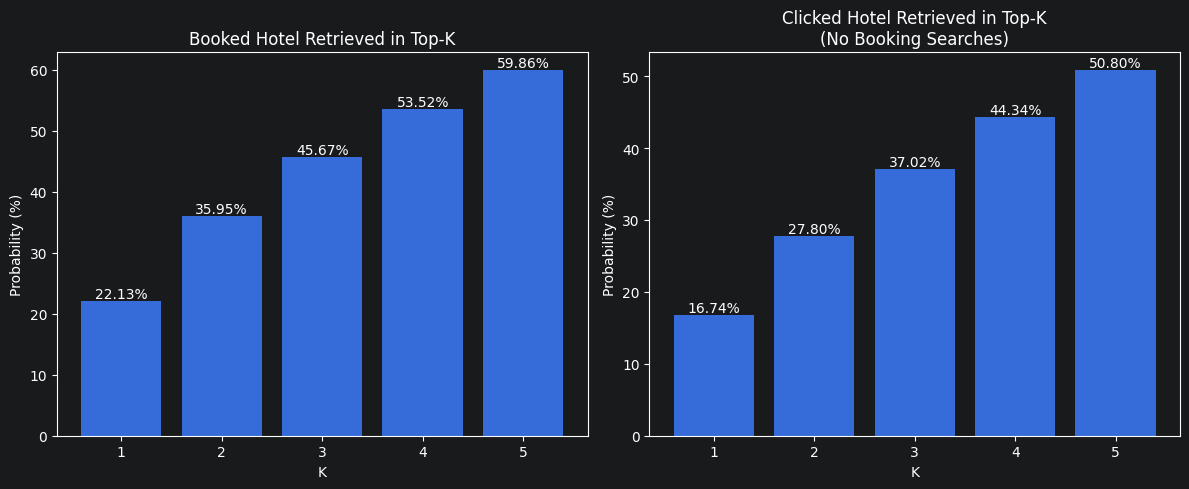

In [29]:
# =========================================================
# EVALUATION of TopK Behavior
# =========================================================

evaluate_topk_behavior(
    model=ranker,
    X=X_val,
    df=val_df
)

### 2.4 Log and Create Test Submission File

In [30]:
'''# ==================================================
# EXPERIMENT CONFIG
# ==================================================

SUBMISSION_NAME = "prop_oof_agg_v1"

# ==================================================
# LOG EXPERIMENT
# ==================================================

experiment_log = log_experiment(
    submission_name=SUBMISSION_NAME,

    val_ndcg5=val_ndcg5,

    params=LGB_PARAMS,

    public_lb=None,

    notes="""
        Added OOF-smoothed property aggregation features:
        - property CTR
        - property booking rate
        - property impression count
        - property price statistics (mean/median/std)
        - property review statistics (mean/median/std)

        Implemented out-of-fold target encoding to prevent leakage.
        Applied Bayesian smoothing to stabilize sparse properties.
        """
)

# ==================================================
# CREATE SUBMISSION FILE
# ==================================================

submission_df = create_submission(
    model=ranker,

    X_test=X_test,

    test_df=test_df,

    submission_name=SUBMISSION_NAME
)'''

'# ==================================================\n# EXPERIMENT CONFIG\n# ==================================================\n\nSUBMISSION_NAME = "prop_oof_agg_v1"\n\n# ==================================================\n# LOG EXPERIMENT\n# ==================================================\n\nexperiment_log = log_experiment(\n    submission_name=SUBMISSION_NAME,\n\n    val_ndcg5=val_ndcg5,\n\n    params=LGB_PARAMS,\n\n    public_lb=None,\n\n    notes="""\n        Added OOF-smoothed property aggregation features:\n        - property CTR\n        - property booking rate\n        - property impression count\n        - property price statistics (mean/median/std)\n        - property review statistics (mean/median/std)\n\n        Implemented out-of-fold target encoding to prevent leakage.\n        Applied Bayesian smoothing to stabilize sparse properties.\n        """\n)\n\n# ==================================================\n# CREATE SUBMISSION FILE\n# ================================